In [3]:
## Load modules ##
import sys;

import scipy.stats
sys.path.insert(0, '../../');
from methods.config import *
import os
import matplotlib.pyplot as plt
import numpy as np; rnd = np.random.default_rng()
import methods.shared as shared
import pickle
import methods.genomics_util as breseq
from importlib import reload
import methods.plot_utils as plot_utils 
reload(breseq)
with open(f'{pickled_dir}/barcode_clone_map.pkl', 'rb') as f:
    barcode_clone_map = pickle.load(f)

with open(f'{pickled_dir}/clone_barcode_map.pkl', 'rb') as f:
    clone_barcode_map = pickle.load(f)

with open(f'{pickled_dir}/mouse_clone_map.pkl', 'rb') as f:
    mouse_clone_map = pickle.load(f)

isolate_gd_dir = f'{data_dir}/isolate_wgs/E1_clones_gd_annotated'
gd_files = os.listdir(isolate_gd_dir)

ordered_barcodes = [(barcode, clones['all']) for barcode, clones in barcode_clone_map.items() if len(barcode) == 20]
ordered_barcodes.sort(key = lambda x:len(x[1]), reverse=True)


This notebook looks through processed metagenomic data and searches for overlapping mutations with those found in vitro

In [ ]:
##generated from process_isolates.ipynb notebook

isolate_driver_loci = {}
isolate_driver_sites = []
with open(f'{tables_dir}/tableS1_putative_driver_mutations.tsv', 'r') as f:
    header = next(f)
    for line in f:
        line = line.strip().split('\t')
        position = int(line[0])
        locus = line[1]

        if locus not in isolate_driver_loci:
            isolate_driver_loci[locus] = []
        isolate_driver_loci[locus].append(position)
        isolate_driver_sites.append( position ) 
        # isolate_driver_sites.append( (position + int(rnd.normal(0, 20000)))) #randomize
isolate_driver_sites = np.array(isolate_driver_sites)

with open(f'{pickled_dir}/all_mutations_in_isolates.pkl', 'rb') as f:
    all_mutations_in_isolates = pickle.load(f)

with open(f'{pickled_dir}/all_vivo_drivers.pkl', 'rb') as f:
    all_vivo_drivers = pickle.load(f)

with open(f'{pickled_dir}/preexisting_variants.pkl', 'rb') as f: 
    preexisting_variants = pickle.load(f)
    preexisting_sites = np.array([variant[0] for variant in preexisting_variants if type(variant[0]) == int])

class NumpyCompatibleUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'numpy._core.numeric':
            module = 'numpy.core.numeric'  # NumPy 2 pickle read by NumPy 1
        return super().find_class(module, name)

def load_pickle(path):
    with open(path, 'rb') as f:
        return NumpyCompatibleUnpickler(f).load()

all_mutation_timecourses = load_pickle(f'{pickled_dir}/metagenomic_mutation_timecourses.pkl')

all_coverage_timecourses = load_pickle(f'{pickled_dir}/metagenomic_coverage_timecourses.pkl')

def check_nearby(pos, arr_of_positions, dist = 1000):
    return np.any(np.abs(pos - arr_of_positions) <= dist)


## Fig. S4D: selection mutation frequency trajectories

In [ ]:
import matplotlib.lines as mlines
# legend handler for plot
class StackedLineHandler:
    def __init__(self, colors=['red', 'blue', 'green'], yoffsets=[0, -0.2, -0.4]):
        self.colors = colors
        self.yoffsets = yoffsets
        
    def legend_artist(self, legend, orig_handle, fontsize, handlebox):
        x0, y0 = handlebox.xdescent, handlebox.ydescent
        width = handlebox.width
        height = handlebox.height
        
        # Create the stacked lines
        lines = []
        for color, yoffset in zip(self.colors, self.yoffsets):
            l = mlines.Line2D(
                [x0, x0 + width], 
                [y0 + height/2 + yoffset, y0 + height/2 + yoffset],
                color=color,
                linewidth=0.5
            )
            lines.append(l)
            handlebox.add_artist(l)
            
        return lines

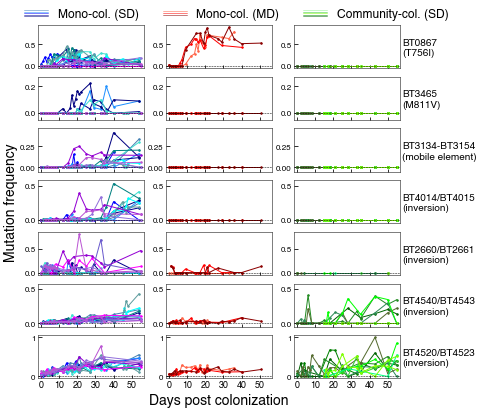

In [10]:
fig = plt.figure(figsize=(6.5,6.5))
gs = fig.add_gridspec(nrows=7, ncols=3, hspace=0.2)
outer_ax = fig.add_subplot(gs[:, :])
plot_utils.turn_off_ax(outer_ax)
outer_ax.set_xlabel('Days post colonization', fontsize=14, labelpad=15)
outer_ax.set_ylabel('Mutation frequency', fontsize=14, labelpad=20)


# Create dummy lines for the legend
line_A = mlines.Line2D([], [], color='white', label='Mono-col. (SD)')
line_B = mlines.Line2D([], [], color='white', label='Mono-col. (MD)')
line_C = mlines.Line2D([], [], color='white', label='Community-col. (SD)')

# Create the legend with custom handlers for each entry
legend = outer_ax.legend(
    handles=[line_A, line_B, line_C],
    handler_map={
        line_A: StackedLineHandler(colors=['steelblue', 'dodgerblue', 'blue', 'darkblue', 'navy'], yoffsets=[3, 1.5, 0, -1.5, -3]),
        line_B: StackedLineHandler(colors=['tomato', 'red', 'darkred'], yoffsets=[2, 0, -2]),
        line_C: StackedLineHandler(colors=['lightgreen', 'limegreen', 'lawngreen', 'green', 'darkgreen'], yoffsets=[3, 1.5, 0, -1.5, -3]),
    },
     loc=(-0.05, 1.0), fontsize=12, frameon=False,bbox_transform=outer_ax.transAxes, ncol=3)



mouse_colors = {('E1', 1):'blue', ('E1', 2):'steelblue', ('E1', 3):'dodgerblue', ('E1', 4):'darkblue', ('E1', 5):'navy',
                 ('E1', 6):'turquoise', ('E1', 7):'teal', ('E1', 8):'darkcyan', ('E1', 9):'aqua', ('E1', 10):'cadetblue',
                 ('E1', 11):'tomato', ('E1', 12):'red', ('E1', 13):'darkred', # MD diet
                 ('E2', 1):'green', ('E2', 2):'darkgreen', ('E2', 3):'forestgreen', ('E2', 4):'seagreen', ('E2', 5):'darkolivegreen',
                 ('E2', 6):'magenta', ('E2', 7):'darkviolet', ('E2', 8):'slateblue', ('E2', 9):'mediumpurple', ('E2', 10):'mediumorchid',
                 ('E2', 11):'lime', ('E2', 12):'limegreen', ('E2', 13):'springgreen', ('E2', 14):'lawngreen', ('E2', 15):'chartreuse'}

plot_mutations = [([1066079], ['BT0867'], 'BT0867\n(T756I)', 0),
                                    ([4463590], ['BT3465'], 'BT3465\n(M811V)', 2),
                                    ([4001887, 4001888, 4001893,4001894, 4001895,4001894, 4017683], [f'BT{e}' for e in range(3134,3155)], 'BT3134-BT3154\n(mobile element)', 4),
                                    ([(5233175, 1, 5233371, 1), (5233192, -1, 5233352, -1)], ['BT4014', 'BT4015'], 'BT4014/BT4015\n(inversion)', 7),
                                    #   ([3907036], ['BT4540'], 'BT4540/BT4543 (inversion)', 5),
                                    ([(3316290, 1, 3316499, 1), (3316302, -1, 3316485,-1)], ['BT2660', 'BT2661'], 'BT2660/BT2661\n(inversion)',6),
                                    # ([(5961716, 1, 5962851, 1), (5961730, -1, 5962835, -1)], ['BT4540', 'BT4541'], 'BT4540/BT4541\n(inversion)', 3),
                                    ([(5961162, 1, 5964550, 1), (5961180, -1, 5964530, -1)], ['BT4540', 'BT4543'], 'BT4540/BT4543\n(inversion)', 5),
                                     ([(5939745, 1, 5943532, 1), (5939754, -1, 5943521, -1)], ['BT4520', 'BT4523'], 'BT4520/BT4523\n(inversion)', 1),
                                    ]

axs = [[fig.add_subplot(gs[row, col]) for col in range(3)] for row in range(7)]
mut_max_freqs = []
for row, ref_mutation in enumerate(plot_mutations):
    positions, genes, label, index = ref_mutation
    row_max_freqs = []
    for col, mice_set in enumerate([[('E1', 1), ('E1', 2), ('E1', 3), ('E1', 4),('E1', 5),
                                     ('E1', 6), ('E1', 7), ('E1', 9), ('E1', 10),
                                     ('E2', 6), ('E2', 7), ('E2', 8), ('E2', 9), ('E2', 10)], 
                                     [('E1', 11), ('E1', 12), ('E1', 13)], 
                                     [('E2', 1), ('E2', 2), ('E2', 3), ('E2', 4),('E2', 5),
                                      ('E2', 11), ('E2', 12), ('E2', 13), ('E2', 14),('E2', 15)]]):
        ax = axs[row][col]
        for (expt, mouse) in mice_set:
            muts = all_mutation_timecourses[(expt, mouse)]
            # continue
            read_lst, cov_lst = [], []
            for pos in positions:
                if pos not in muts:
                    continue
                else:
                    mut, reads, cov = muts[pos]
                    days = np.copy(muts['days'])
                    read_lst.append(reads)
                    cov_lst.append(cov)
        
            if len(read_lst)==0: #mut not detected
                locus = ref_mutation[2].split('\n')[0]
                coverage_timecourse = all_coverage_timecourses[(expt, mouse)][locus]
                days = np.copy(coverage_timecourse['times'])
                cov_lst = [coverage_timecourse['average_coverage']]
                read_lst = [np.zeros(len(cov_lst))] # if mutation is not detected, set reads to 0
                # not detected by metagenomics, so instead plot coverage

            read_lst, cov_lst = np.array(read_lst).sum(axis=0), np.array(cov_lst).sum(axis=0)
            with np.errstate(divide='ignore', invalid='ignore'):
                avg_freqs = read_lst / cov_lst
        
    
            row_max_freqs.append(np.max(avg_freqs[~np.isnan(avg_freqs)]))
            days = np.array(days)
            if 200 in days: # exclude small intestine from plot
                avg_freqs = avg_freqs[:-1]
                days = days[:-1]
                cov_lst = cov_lst[:-1]
            if 100 in days: # exclude cecum from plot
                avg_freqs = avg_freqs[:-1]
                days = days[:-1]
                cov_lst = cov_lst[:-1]

    
            if expt == 'E2' and mouse in [1,2,3,4,5,11,12,13,14,15]:
                mask = cov_lst > 2
            else:
                mask = cov_lst > 2


            if expt == 'E1' and mouse not in [11,12,13] and 'inversion' not in label and 'mobile element' not in label:
                ax.plot(days[mask], avg_freqs[mask][::-1], color=mouse_colors[(expt, mouse)], marker='.', markersize=3, label=f'Mouse {mouse}', lw=1)
            else:
                ax.plot(days[mask], avg_freqs[mask], color=mouse_colors[(expt, mouse)], marker='.', markersize=3, label=f'Mouse {mouse}', lw=1)

        
        ax.set_ylim(ax.get_ylim()[0], ax.get_ylim()[1]+0.1)
        # ax.text(0.5, 0.97, label, transform=ax.transAxes, ha='center', va='top', fontsize=10) 
        ax.set_xlim(-2, 57)
        ax.set_xticks([0,10,20,30,40,50])
        ax.set_xticklabels([0,10,20,30,40,50],fontsize=9)
        # ax.set_yticks(ax.get_yticks())
        # ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)
        ax.spines['top'].set_linewidth(0.5)
        ax.spines['right'].set_linewidth(0.5)
        ax.spines['bottom'].set_linewidth(0.5)
        ax.spines['left'].set_linewidth(0.5)
        if row != len(plot_mutations) - 1:
            ax.set_xticklabels([])  
        if col == 2:
            ax.text(1.02, 0.7, label, transform=ax.transAxes, ha='left', va='top', fontsize=10)


        ax.axhline(0, color='black', linestyle='--', lw=0.5)
    row_max_freqs = [e for e in row_max_freqs if not np.isnan(e)]
    mut_max_freqs.append(np.max(row_max_freqs))

        
for row in range(len(plot_mutations)):
    for col in range(3):
        axs[row][col].set_ylim(-0.05, mut_max_freqs[row]+0.05)

plt.rcParams['svg.fonttype'] = 'none'
fig.savefig(f'{figures_dir}/invivo_metagenomic_trajectories.svg', format='svg', transparent=True, bbox_inches='tight', dpi=1000)
fig.savefig(f'{figures_dir}/invivo_metagenomic_trajectories.pdf', transparent=True, bbox_inches='tight', dpi=1000)


In [ ]:
## reviewer request for fig. 4
FIG4_SNP_GENES = ['BT0317',  ## 2 clones mouse E1 1, day 51, site 383724 A->G... maybe?
                  'BT0867',  # YES
                  'BT1046',  ##3 clones mice E1 11, E1 12 (x2), days 17, 36, 51, site 1327508 G->T.. YES
                  'BT1573', ## 9 clones mice E1 12, days 36-51 site 1937088/1937089 DEL YES
                  'BT3082', # 5 clones mouse E1 12, days 51 3907036  C->T YES
                  'BT3465', # YES
                  'BT4245', # 3 clones mouse 12, days 51 site 5593787 INS YES
                  'BT4247', # 2/3 clones as BT4245, site 5598011 C->T YES
                  'BT4295' # 2 clones mouse 8 day 36, site 5657731 G->A
                  ]

FIG4_SNP_GENE_BARCODES = {'BT0317': ('ATGCTAAGACGCGACATGAT', [1,2,3], 383724),
                          #'BT0867': 'TCCGTTAACCTTCATAGTTG',
                          'BT1046': ('TTGTTCTCCATGTAATTTAC', [11,12,13], 1327508),
                          'BT1573': ('TTTAAGCCAGGGCAGTGTAA', [11,12,13], 1937089),
                          'BT3082': ('TCTTATCACAACTATCTTTC', [11,12,13], 3907036),
                          'BT3465': ('CCGTTACATGCGTTCTTGGT', [1,2,3], 4463590),
                          'BT4245': ('GGAATATAATACCATATGTC', [11,12,13], 5593787),
                          #'BT4247': ("GGAATATAATACCATATGTC", [11,12,13], 5598011),
                          'BT4295': ('TACTCCACCCTCTCATTACA', [8,9,10], 5657731),
                           'BT0900': ('TGTAGTAGGCATAATAACCC', [1,2,3], 1110670)}


# for gene in FIG4_SNP_GENES[:]:
for gene in ['BT0900']:
    print(f"GENE: {gene}")
    gene_start, gene_stop, strand = shared.gene_coords_map[gene]
    for (expt, mouse), muts in all_mutation_timecourses.items():
        days = muts['days'][:-1] # exclude small intestine
        if expt == 'E2' and mouse in [1,2,3,4,5,11,12,13,14,15]:
            continue # community-colonized mice
        
        print(f"\tMouse: {expt} {mouse} {list(zip(days, cov))}")
        for pos in muts:
            if type(pos) != int:
                continue
            if pos < gene_start or pos > gene_stop:
                continue
            
            mut, reads, cov = muts[pos]
            reads, cov = reads[:-1], cov[:-1] # exclude small intestine
            freqs = reads / cov

            
            # if np.max(freqs[days > 7]) < 0.01 or np.max(reads[ days > 7]) < 1:
            #     continue

            # print(freqs, cov)
            
            # print(f"\t\tPosition: {pos}, Mutation: {mut}, freqs: {freqs}")
            print(f"\t\tPosition: {pos}, Mutation: {mut}, Max freq (day>7): {np.max(freqs[days > 7]):.3f}, day: {days[np.argmax(freqs)]}, reads: {reads[np.argmax(freqs)]}, cov: {cov[np.argmax(freqs)]}")
            



GENE: BT0900
	Mouse: E1 10 [(np.int64(0), np.float64(0.0)), (np.int64(1), np.float64(0.0)), (np.int64(2), np.float64(0.0)), (np.int64(3), np.float64(0.0)), (np.int64(4), np.float64(0.0)), (np.int64(5), np.float64(0.0)), (np.int64(6), np.float64(0.0)), (np.int64(7), np.float64(0.0)), (np.int64(9), np.float64(0.0)), (np.int64(12), np.float64(0.0)), (np.int64(14), np.float64(0.0)), (np.int64(16), np.float64(9.7)), (np.int64(17), np.float64(16.6)), (np.int64(18), np.float64(4.0)), (np.int64(19), np.float64(5.9)), (np.int64(20), np.float64(5.9)), (np.int64(21), np.float64(9.6)), (np.int64(22), np.float64(11.6)), (np.int64(27), np.float64(3.8)), (np.int64(29), np.float64(2.9)), (np.int64(33), np.float64(4.8)), (np.int64(36), np.float64(0.0))]
		Position: 1110776, Mutation: G->T, Max freq (day>7): 0.125, day: 40, reads: 2.0, cov: 16.0
		Position: 1111096, Mutation: C->A, Max freq (day>7): 0.077, day: 47, reads: 2.0, cov: 26.0
	Mouse: E1 11 [(np.int64(0), np.float64(73.0)), (np.int64(1), np.fl

## Unused figure
### Overlayed trajectories of barcode and mutation frequency trajectories, for barcode in which mutation was identified

left column = barcode
right column = corresponding mutation

BT0867_c1 ATGAACAACCTCAGCCGAGC
[3.48430488e-06 5.66109407e-07 1.00000000e-07 2.72827464e-05
 3.41921804e-05 3.51388757e-05 2.62126180e-05 2.62786101e-05
 1.00000000e-07 2.35948681e-05 1.00000000e-07 1.40926781e-06
 1.35852448e-04 2.33439584e-05 1.13132623e-05 2.65916816e-05
 6.62469920e-07 1.00000000e-07 6.56217497e-06 1.42465238e-05
 3.02826654e-05 1.00000000e-07 6.68873636e-05 6.95970747e-07
 2.30621399e-05]
[3.48430488e-06 5.54004343e-07 9.82436009e-07 1.93196229e-05
 2.62230682e-05 3.81620197e-05 3.28368597e-05 2.94450793e-05
 5.97572660e-06 2.34320228e-05 2.56347648e-05 2.78189498e-05
 8.69221913e-05 1.29919609e-06 3.57958747e-07 6.96339155e-05
 3.89140490e-07 1.62854779e-05 1.84724135e-05 2.58306872e-05
 4.35080923e-07 2.35710582e-05 2.46851028e-05]
[3.48430488e-06 1.55594074e-06 1.00000000e-07 3.95765914e-05
 1.66184915e-05 4.05333716e-05 2.73331437e-05 3.98061704e-05
 2.11255246e-05 2.83642210e-05 1.59506551e-06 4.41720648e-05
 4.72432166e-07 8.48946881e-07 5.56815157e-05 1.000

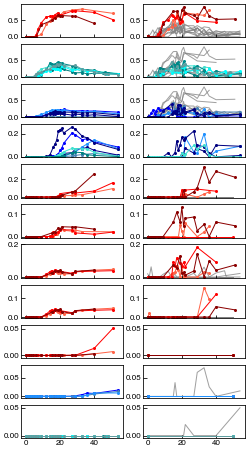

In [105]:
FIG4_SNP_GENE_BARCODES = {'BT0867_c1': ('ATGAACAACCTCAGCCGAGC', range(11,14), 1066079),
                          'BT0867_c2': ('TCCGTTAACCTTCATAGTTG', range(6,11), 1066079),
                          'BT0867_c3': ('CGGTTGCGGTATTACAAGTC', range(1,6), 1066079),
                          'BT3465': ('CCGTTACATGCGTTCTTGGT', [1,2,3,4,5,6,7], 4463590),
                          'BT1573': ('TTTAAGCCAGGGCAGTGTAA', [11,12,13], 1937088),
                          'BT1046': ('TTGTTCTCCATGTAATTTAC', [11,12,13], 1327508),
                          'BT4245': ('GGAATATAATACCATATGTC', [11,12,13], 5593783),
                          'BT4247': ('GGAATATAATACCATATGTC', [11,12,13], 5598011),
                          'BT3082': ('TCTTATCACAACTATCTTTC', [11,12,13], 3907036),
                          'BT0317': ('ATGCTAAGACGCGACATGAT', [1,2,3], 383724),
                          'BT4295': ('TACTCCACCCTCTCATTACA', [8,9,10], 5657731) 
                          }
                        #    'BT0900': ('TGTAGTAGGCATAATAACCC', [1,2,3], 1110670) }

expt = 'E1'

fig, axs = plt.subplots(nrows=11, ncols=2, figsize=(4,8), sharex=True)

mouse_colors = {1:'blue', 2:'steelblue', 3:'dodgerblue', 4:'darkblue', 5:'navy',
                 6:'turquoise', 7:'teal', 8:'darkcyan', 9:'aqua', 10:'cadetblue',
                 11:'tomato', 12:'red', 13:'darkred'} # MD diet

for row, (gene, (barcode, mice, site)) in enumerate(FIG4_SNP_GENE_BARCODES.items()):
    barcode_ax = axs[row, 0]
    mgx_ax = axs[row, 1]

    try:
       bc_index = np.where(shared.barcodes == barcode)[0][0]
       print(gene, barcode)
    except:
       print(f'barcode not found for gene {gene}: {barcode}')
       bc_index = -1 # set to random low frequency barcode... 

    max_val = 0.01
    for mouse in range(1,14):
        days, reads, depths = shared.get_mouse_timecourse(expt, mouse, min_depth=10**4)
        bc_freqs = shared.calc_freqs(reads,depths)[:, bc_index]
        bc_freqs[bc_freqs == 0] = 1e-7
        print(bc_freqs)


        muts = all_mutation_timecourses[(expt, mouse)]
        mgx_days = muts['days'][:-1] # exclude small intestine
    
        if site not in muts:
            print(f'not detected: {gene} {mouse}')
            mgx_days = np.array([0,50])
            mgx_freqs = np.array([0,0])

    
        else:
            mut, mgx_reads, mgx_cov = muts[site]
            mgx_freqs = mgx_reads / mgx_cov
            mgx_freqs = mgx_freqs[:-1] # exclude small intestine

            where_nan = np.isnan(mgx_freqs)
            mgx_freqs = mgx_freqs[~where_nan]
            mgx_days = mgx_days[~where_nan]

            if mouse < 11:
                mgx_freqs = mgx_freqs[::-1]  # invert for SD mice to match barcode orientation

        if mouse in mice:
            barcode_ax.plot(days, bc_freqs, marker='.', markersize=4, lw=1, label=f'Mouse {mouse}', color=mouse_colors[mouse])
            mgx_ax.plot(mgx_days, mgx_freqs, marker='.', markersize=4, lw=1, label=f'Mouse {mouse}', color=mouse_colors[mouse])
        else:
            # barcode_ax.plot(days, bc_freqs,  markersize=4, lw=1, color='grey', alpha=0.75, zorder=0)
            mgx_ax.plot(mgx_days, mgx_freqs, markersize=4, lw=1, color='grey', alpha=0.75, zorder=0)

        new_max = np.max([max_val, np.max(bc_freqs[ np.isfinite(bc_freqs)]), np.max(mgx_freqs[ np.isfinite(mgx_freqs) ])])
    
    if  barcode_ax.get_ylim()[1] > 1:
        barcode_ax.set_ylim(-0.005, 0.05)
    if  mgx_ax.get_ylim()[1] > 1:
        mgx_ax.set_ylim(-0.005, 0.05)

    max_y = np.min([1.0, np.max([barcode_ax.get_ylim()[1], mgx_ax.get_ylim()[1]])])
    barcode_ax.set_ylim(-0.005, max_y*1.05)
    mgx_ax.set_ylim(-0.005, max_y*1.05)

